In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

# Create project directories

import os

PROJECT_ROOT = "/content/drive/MyDrive/CSC8645_Task1"
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_ROOT = os.path.join(PROJECT_ROOT, "checkpoints")
RESULTS_ROOT = os.path.join(PROJECT_ROOT, "results")

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(RESULTS_ROOT, exist_ok=True)

print("Project folders created successfully.")
print("Project root:", PROJECT_ROOT)

Mounted at /content/drive
Project folders created successfully.
Project root: /content/drive/MyDrive/CSC8645_Task1


In [ ]:
# Copy ZIP to local runtime

!cp /content/drive/MyDrive/Advanced_AI/Task_1_Food_Segmentation_Dataset.zip /content/

print("ZIP copied to /content")

!unzip -q /content/Task_1_Food_Segmentation_Dataset.zip -d /content/

print("Dataset extracted to /content")

# Verify structure

import os

DATA_ROOT = "/content/Task 1 Food Segmentation Dataset/FoodSeg103"

print("Checking extracted folders:")
print(os.listdir(DATA_ROOT))

ZIP copied to /content
Dataset extracted to /content
Checking extracted folders:
['Readme.txt', 'category_id.txt', 'ImageSets', 'Images']


In [ ]:
# Dataset Sanity Check

import os

DATA_ROOT = "/content/Task 1 Food Segmentation Dataset/FoodSeg103"

train_img_dir = os.path.join(DATA_ROOT, "Images", "img_dir", "train")
train_mask_dir = os.path.join(DATA_ROOT, "Images", "ann_dir", "train")

test_img_dir = os.path.join(DATA_ROOT, "Images", "img_dir", "test")
test_mask_dir = os.path.join(DATA_ROOT, "Images", "ann_dir", "test")

# Count files
num_train_imgs = len(os.listdir(train_img_dir))
num_train_masks = len(os.listdir(train_mask_dir))

num_test_imgs = len(os.listdir(test_img_dir))
num_test_masks = len(os.listdir(test_mask_dir))

print("Train images:", num_train_imgs)
print("Train masks:", num_train_masks)
print("Test images:", num_test_imgs)
print("Test masks:", num_test_masks)

# Check filename alignment (first 5 samples)
train_img_sample = sorted(os.listdir(train_img_dir))[:5]
train_mask_sample = sorted(os.listdir(train_mask_dir))[:5]

print("\nSample train image names:", train_img_sample)
print("Sample train mask names:", train_mask_sample)

Train images: 4983
Train masks: 4983
Test images: 2135
Test masks: 2135

Sample train image names: ['00000000.jpg', '00000001.jpg', '00000002.jpg', '00000003.jpg', '00000004.jpg']
Sample train mask names: ['00000000.png', '00000001.png', '00000002.png', '00000003.png', '00000004.png']


In [ ]:
# Install Dependencies

!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics

print("All libraries installed successfully.")

import torch
print("Torch version:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.0 MB/s eta 0:00:00
All libraries installed successfully.
Torch version: 2.10.0+cu128
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
# Create Dataset Class

import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_ROOT = "/content/Task 1 Food Segmentation Dataset/FoodSeg103"

class FoodSegDataset(Dataset):
    def __init__(self, split="train", transform=None):
        self.split = split
        self.transform = transform

        self.img_dir = os.path.join(DATA_ROOT, "Images", "img_dir", split)
        self.mask_dir = os.path.join(DATA_ROOT, "Images", "ann_dir", split)

        self.images = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # mask has same name but png extension
        mask_name = img_name.replace(".jpg", ".png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask

# Define Transformations

train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(),
    ToTensorV2(),
])

print("Dataset class defined successfully.")

Dataset class defined successfully.


In [ ]:
train_dataset = FoodSegDataset(split="train", transform=train_transform)

img, mask = train_dataset[0]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Unique mask values (first sample):", torch.unique(mask)[:20])

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([512, 512])
Unique mask values (first sample): tensor([ 0, 48, 66, 90], dtype=torch.uint8)


In [ ]:
# Train/Val Split + DataLoaders

from torch.utils.data import DataLoader, random_split

# Create full training dataset
full_train_dataset = FoodSegDataset(split="train", transform=train_transform)

# Define split sizes
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_transform

# DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 3986
Validation size: 997


In [ ]:
# mIoU Metric

import torch

NUM_CLASSES = 104

def compute_miou(preds, masks, num_classes=NUM_CLASSES):
    """
    preds: (B, H, W)
    masks: (B, H, W)
    """

    preds = preds.view(-1)
    masks = masks.view(-1)

    iou_per_class = []

    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = masks == cls

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:

            continue

        iou = intersection / union
        iou_per_class.append(iou)

    if len(iou_per_class) == 0:
        return 0.0

    return sum(iou_per_class) / len(iou_per_class)


print("mIoU function defined successfully.")

mIoU function defined successfully.


In [ ]:
pred = torch.randint(0, 104, (2, 512, 512))
mask = torch.randint(0, 104, (2, 512, 512))

miou_score = compute_miou(pred, mask)

print("Random test mIoU:", miou_score)

Random test mIoU: 0.004784229019854074


In [ ]:
# Build Baseline Model
# DeepLabV3 + ResNet50

import segmentation_models_pytorch as smp
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.DeepLabV3(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)

model = model.to(DEVICE)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print("Baseline Model Loaded Successfully")
print("Model on device:", DEVICE)

Baseline Model Loaded Successfully
Model on device: cuda


In [ ]:
# Quick forward pass test

sample_images, sample_masks = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)

with torch.no_grad():
    output = model(sample_images)

print("Output shape:", output.shape)

Output shape: torch.Size([16, 104, 512, 512])


In [ ]:
# Training Loop

import os
from tqdm import tqdm
import torch.cuda.amp as amp

CHECKPOINT_PATH = "/content/drive/MyDrive/CSC8645_Task1/checkpoints"
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

EPOCHS = 15

scaler = amp.GradScaler()

best_miou = 0.0

train_losses = []
val_losses = []
val_mious = []

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")


    # TRAINING

    model.train()
    running_loss = 0.0

    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.long().to(DEVICE)

        optimizer.zero_grad()

        with amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    total_miou = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader):
            images = images.to(DEVICE)
            masks = masks.long().to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            batch_miou = compute_miou(preds.cpu(), masks.cpu())
            total_miou += batch_miou

    val_loss /= len(val_loader)
    val_miou = total_miou / len(val_loader)

    val_losses.append(val_loss)
    val_mious.append(val_miou)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val mIoU: {val_miou:.4f}")

    # Save Best Model
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_PATH, "baseline_best.pth"))
        print("✅ Best model saved!")

    # Save last checkpoint
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_PATH, "baseline_last.pth"))

print("\nTraining Complete.")
print("Best Validation mIoU:", best_miou)

/tmp/ipykernel_632/3608271165.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()



Epoch [1/15]


  0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_632/3608271165.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
100%|██████████| 63/63 [02:42<00:00,  2.57s/it]


Train Loss: 2.1060
Val Loss: 1.4932
Val mIoU: 0.1933
✅ Best model saved!

Epoch [2/15]


100%|██████████| 63/63 [02:37<00:00,  2.49s/it]


...

Train Loss: 0.2467
Val Loss: 1.0231
Val mIoU: 0.2639

Epoch [14/15]


100%|██████████| 63/63 [02:34<00:00,  2.45s/it]


Train Loss: 0.2664
Val Loss: 1.0941
Val mIoU: 0.2419

Epoch [15/15]


100%|██████████| 63/63 [02:34<00:00,  2.46s/it]


Train Loss: 0.2379
Val Loss: 1.0925
Val mIoU: 0.2606

Training Complete.
Best Validation mIoU: 0.2675632949073538


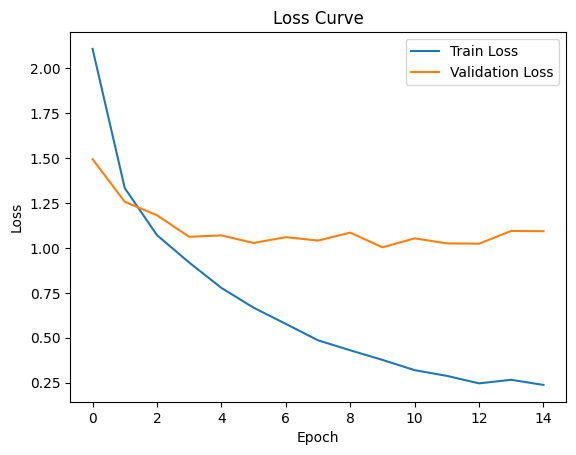

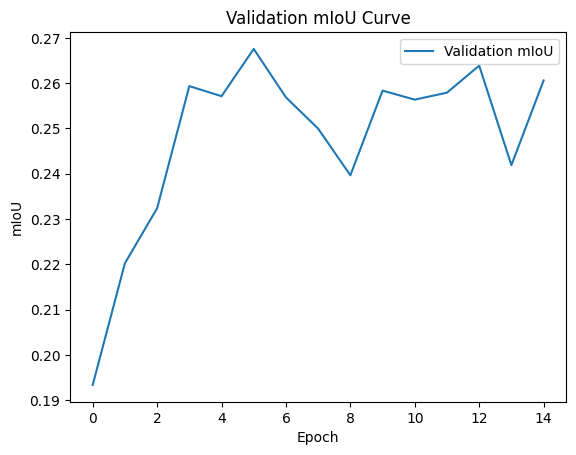

In [ ]:
# Plot Training Curves

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(val_mious, label="Validation mIoU")
plt.legend()
plt.title("Validation mIoU Curve")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.show()

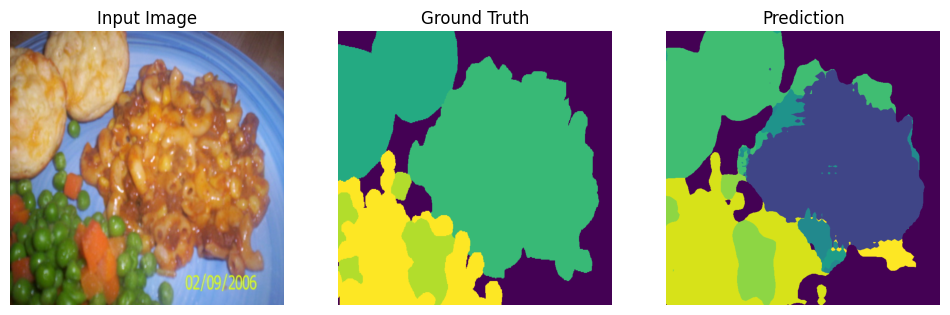

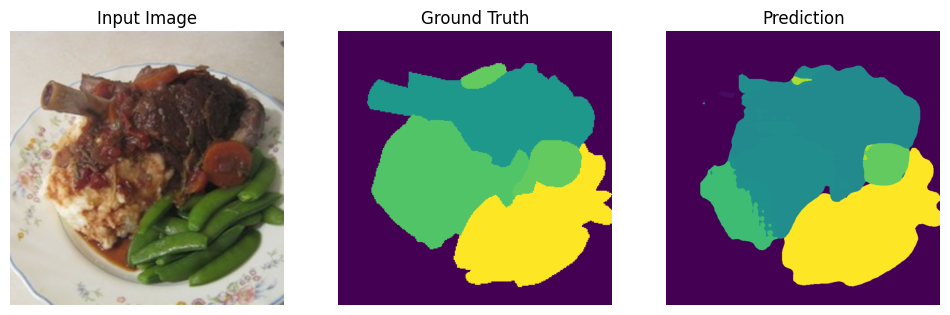

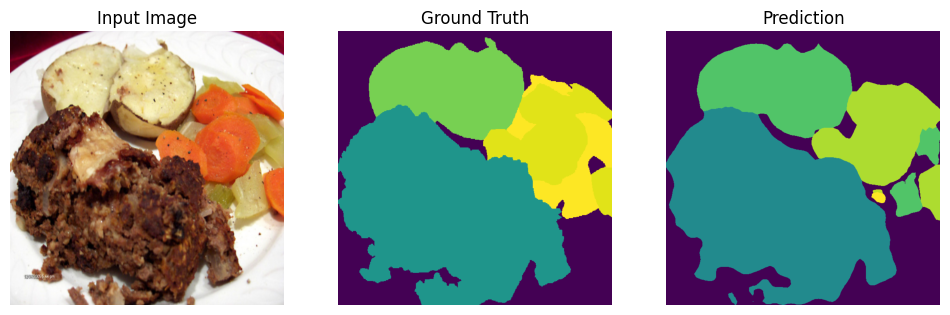

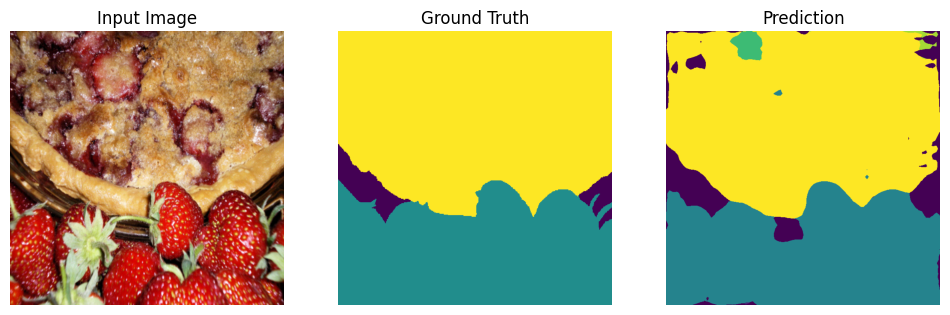

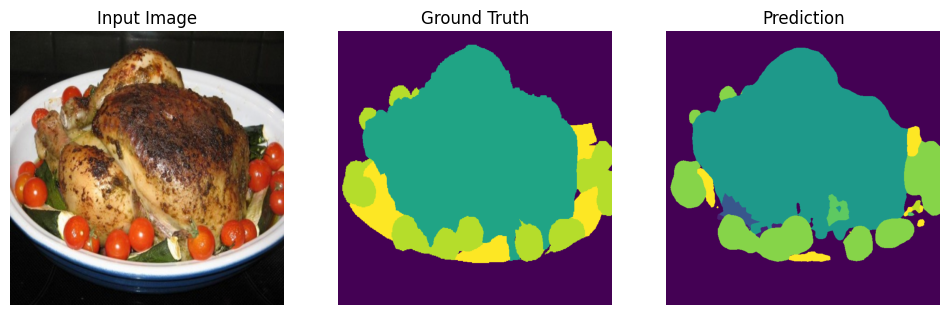

In [ ]:
# Visualize Predictions

import matplotlib.pyplot as plt

model.load_state_dict(torch.load("/content/drive/MyDrive/CSC8645_Task1/checkpoints/baseline_best.pth"))
model.eval()

images, masks = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# Move to CPU
images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

# Denormalization function
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img.clamp(0,1)

for i in range(5):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    img = denormalize(images[i])
    plt.imshow(img.permute(1,2,0))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(masks[i])
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(preds[i])
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

In [ ]:
# Build Improved Model
# DeepLabV3+ + ResNet101

import segmentation_models_pytorch as smp
import torch.nn as nn

improved_model = smp.DeepLabV3Plus(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)

improved_model = improved_model.to(DEVICE)

criterion_improved = nn.CrossEntropyLoss()

optimizer_improved = torch.optim.AdamW(improved_model.parameters(), lr=1e-4)

print("Improved Model Loaded Successfully")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Improved Model Loaded Successfully


In [ ]:
sample_images, sample_masks = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)

with torch.no_grad():
    output = improved_model(sample_images)

print("Output shape:", output.shape)

Output shape: torch.Size([16, 104, 512, 512])


In [ ]:
# Train Improved Model

import os
from tqdm import tqdm
import torch.cuda.amp as amp

CHECKPOINT_PATH = "/content/drive/MyDrive/CSC8645_Task1/checkpoints"

EPOCHS = 15

scaler = amp.GradScaler()

best_miou_improved = 0.0

train_losses_improved = []
val_losses_improved = []
val_mious_improved = []

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # TRAIN
    improved_model.train()
    running_loss = 0.0

    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.long().to(DEVICE)

        optimizer_improved.zero_grad()

        with amp.autocast():
            outputs = improved_model(images)
            loss = criterion_improved(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer_improved)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses_improved.append(train_loss)

    # VALIDATION
    improved_model.eval()
    val_loss = 0.0
    total_miou = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader):
            images = images.to(DEVICE)
            masks = masks.long().to(DEVICE)

            outputs = improved_model(images)
            loss = criterion_improved(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            batch_miou = compute_miou(preds.cpu(), masks.cpu())
            total_miou += batch_miou

    val_loss /= len(val_loader)
    val_miou = total_miou / len(val_loader)

    val_losses_improved.append(val_loss)
    val_mious_improved.append(val_miou)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val mIoU: {val_miou:.4f}")

    # Save best
    if val_miou > best_miou_improved:
        best_miou_improved = val_miou
        torch.save(improved_model.state_dict(),
                   os.path.join(CHECKPOINT_PATH, "improved_best.pth"))
        print("Improved Best model saved!")

    # Save last
    torch.save(improved_model.state_dict(),
               os.path.join(CHECKPOINT_PATH, "improved_last.pth"))

print("\nImproved Training Complete.")
print("Best Validation mIoU:", best_miou_improved)

/tmp/ipykernel_632/2273189251.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()



Epoch [1/15]


  0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_632/2273189251.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
100%|██████████| 63/63 [02:32<00:00,  2.41s/it]


Train Loss: 2.3465
Val Loss: 1.6323
Val mIoU: 0.1710
✅ Improved Best model saved!

Epoch [2/15]


100%|██████████| 63/63 [02:30<00:00,  2.39s/it]


...

Train Loss: 0.2805
Val Loss: 1.0880
Val mIoU: 0.2568

Epoch [14/15]


100%|██████████| 63/63 [02:32<00:00,  2.41s/it]


Train Loss: 0.2508
Val Loss: 1.0908
Val mIoU: 0.2502

Epoch [15/15]


100%|██████████| 63/63 [02:31<00:00,  2.40s/it]


Train Loss: 0.2181
Val Loss: 1.1705
Val mIoU: 0.2279

Improved Training Complete.
Best Validation mIoU: 0.2592359809654114


In [ ]:
print("Baseline Best mIoU:", best_miou)
print("Improved Best mIoU:", best_miou_improved)

Baseline Best mIoU: 0.2675632949073538
Improved Best mIoU: 0.2592359809654114


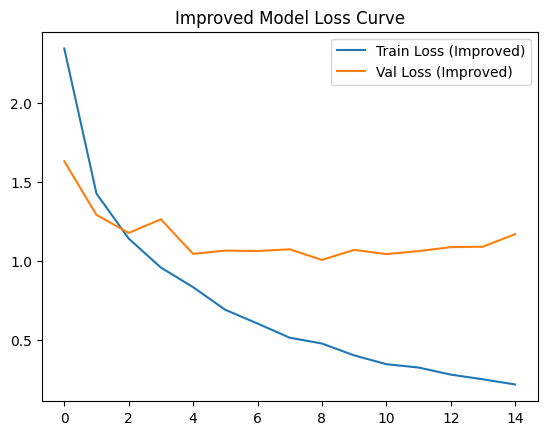

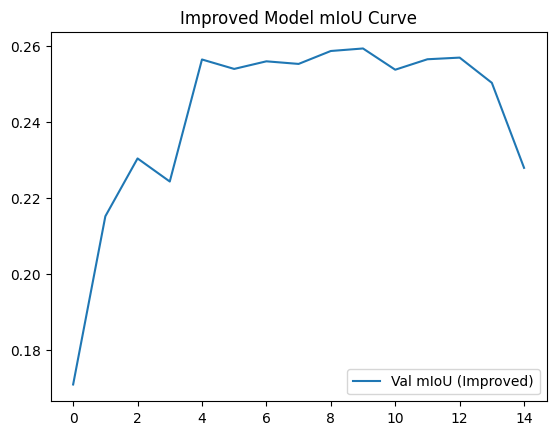

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses_improved, label="Train Loss (Improved)")
plt.plot(val_losses_improved, label="Val Loss (Improved)")
plt.legend()
plt.title("Improved Model Loss Curve")
plt.show()

plt.figure()
plt.plot(val_mious_improved, label="Val mIoU (Improved)")
plt.legend()
plt.title("Improved Model mIoU Curve")
plt.show()

In [ ]:
improved_model.load_state_dict(
    torch.load("/content/drive/MyDrive/CSC8645_Task1/checkpoints/improved_best.pth")
)
improved_model.eval()

DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [ ]:
'''

# ============================
# Combined Loss + Scheduler
# ============================

import segmentation_models_pytorch as smp
import torch.nn as nn

# Combined Loss
dice_loss = smp.losses.DiceLoss(mode="multiclass")
ce_loss = nn.CrossEntropyLoss()

def combined_loss(outputs, targets):
    return ce_loss(outputs, targets) + dice_loss(outputs, targets)

# Optimizer
optimizer_improved = torch.optim.AdamW(improved_model.parameters(), lr=1e-4)

# LR Scheduler (reduce LR if mIoU plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_improved,
    mode='max',        # because we monitor mIoU
    patience=3,
    factor=0.5
)

print("Combined loss and scheduler defined.")

'''

'\n\n# ============================\n# Combined Loss + Scheduler\n# ============================\n\nimport segmentation_models_pytorch as smp\nimport torch.nn as nn\n\n# Combined Loss\ndice_loss = smp.losses.DiceLoss(mode="multiclass")\nce_loss = nn.CrossEntropyLoss()\n\ndef combined_loss(outputs, targets):\n    return ce_loss(outputs, targets) + dice_loss(outputs, targets)\n\n# Optimizer\noptimizer_improved = torch.optim.AdamW(improved_model.parameters(), lr=1e-4)\n\n# LR Scheduler (reduce LR if mIoU plateaus)\nscheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(\n    optimizer_improved,\n    mode=\'max\',        # because we monitor mIoU\n    patience=3,\n    factor=0.5\n)\n\nprint("Combined loss and scheduler defined.")\n\n'

In [ ]:
# ============================
# Improved Training (Upgraded)
# ============================
'''
EPOCHS = 15

scaler = torch.cuda.amp.GradScaler()

best_miou_improved = 0.0

train_losses_improved = []
val_losses_improved = []
val_mious_improved = []

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # ----------------------
    # TRAIN
    # ----------------------
    improved_model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.long().to(DEVICE)

        optimizer_improved.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = improved_model(images)
            loss = combined_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer_improved)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses_improved.append(train_loss)

    # ----------------------
    # VALIDATION
    # ----------------------
    improved_model.eval()
    val_loss = 0.0
    total_miou = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.long().to(DEVICE)

            outputs = improved_model(images)
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            batch_miou = compute_miou(preds.cpu(), masks.cpu())
            total_miou += batch_miou

    val_loss /= len(val_loader)
    val_miou = total_miou / len(val_loader)

    val_losses_improved.append(val_loss)
    val_mious_improved.append(val_miou)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val mIoU: {val_miou:.4f}")

    # Step scheduler based on mIoU
    scheduler.step(val_miou)

    # Save best model
    if val_miou > best_miou_improved:
        best_miou_improved = val_miou
        torch.save(improved_model.state_dict(),
                   "/content/drive/MyDrive/CSC8645_Task1/checkpoints/improved_best.pth")
        print("✅ Improved Best model saved!")

    # Save last
    torch.save(improved_model.state_dict(),
               "/content/drive/MyDrive/CSC8645_Task1/checkpoints/improved_last.pth")

print("\nImproved Training Complete.")
print("Best Validation mIoU:", best_miou_improved)

'''

'\nEPOCHS = 15\n\nscaler = torch.cuda.amp.GradScaler()\n\nbest_miou_improved = 0.0\n\ntrain_losses_improved = []\nval_losses_improved = []\nval_mious_improved = []\n\nfor epoch in range(EPOCHS):\n    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")\n\n    # ----------------------\n    # TRAIN\n    # ----------------------\n    improved_model.train()\n    running_loss = 0.0\n\n    for images, masks in train_loader:\n        images = images.to(DEVICE)\n        masks = masks.long().to(DEVICE)\n\n        optimizer_improved.zero_grad()\n\n        with torch.cuda.amp.autocast():\n            outputs = improved_model(images)\n            loss = combined_loss(outputs, masks)\n\n        scaler.scale(loss).backward()\n        scaler.step(optimizer_improved)\n        scaler.update()\n\n        running_loss += loss.item()\n\n    train_loss = running_loss / len(train_loader)\n    train_losses_improved.append(train_loss)\n\n    # ----------------------\n    # VALIDATION\n    # ----------------------\n    impr

In [ ]:
'''
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses_improved, label="Train Loss (Improved)")
plt.plot(val_losses_improved, label="Val Loss (Improved)")
plt.legend()
plt.title("Improved Model Loss Curve")
plt.show()

plt.figure()
plt.plot(val_mious_improved, label="Val mIoU (Improved)")
plt.legend()
plt.title("Improved Model mIoU Curve")
plt.show()
'''

'\nimport matplotlib.pyplot as plt\n\nplt.figure()\nplt.plot(train_losses_improved, label="Train Loss (Improved)")\nplt.plot(val_losses_improved, label="Val Loss (Improved)")\nplt.legend()\nplt.title("Improved Model Loss Curve")\nplt.show()\n\nplt.figure()\nplt.plot(val_mious_improved, label="Val mIoU (Improved)")\nplt.legend()\nplt.title("Improved Model mIoU Curve")\nplt.show()\n'

# TEST DATASET

In [ ]:
# ============================
# Create Test Loader
# ============================

test_dataset = FoodSegDataset(split="test", transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Test size:", len(test_dataset))

Test size: 2135


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    total_miou = 0.0
    total_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(DEVICE)
            masks = masks.long().to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            total_miou += compute_miou(preds.cpu(), masks.cpu())

    avg_loss = total_loss / len(loader)
    avg_miou = total_miou / len(loader)

    return avg_loss, avg_miou

In [ ]:
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/CSC8645_Task1/checkpoints/baseline_best.pth"
))

baseline_test_loss, baseline_test_miou = evaluate_model(model, test_loader)

print("Baseline Test mIoU:", baseline_test_miou)

Baseline Test mIoU: 0.26361818614209837


In [ ]:
improved_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/CSC8645_Task1/checkpoints/improved_best.pth"
))

improved_test_loss, improved_test_miou = evaluate_model(improved_model, test_loader)


print("Improved Test mIoU:", improved_test_miou)

Improved Test mIoU: 0.2431955353338721


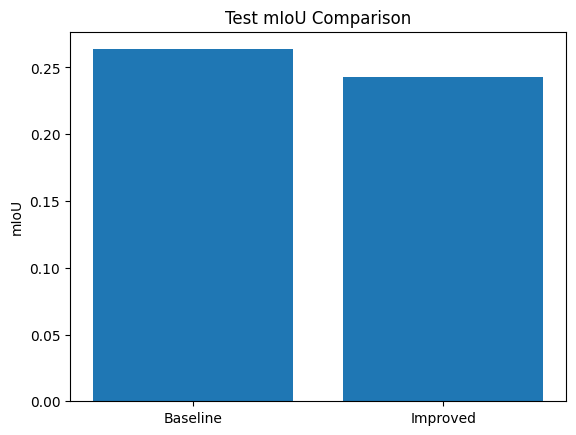

In [ ]:
import matplotlib.pyplot as plt

models = ["Baseline", "Improved"]
miou_scores = [baseline_test_miou, improved_test_miou]

plt.figure()
plt.bar(models, miou_scores)
plt.title("Test mIoU Comparison")
plt.ylabel("mIoU")

plt.show()

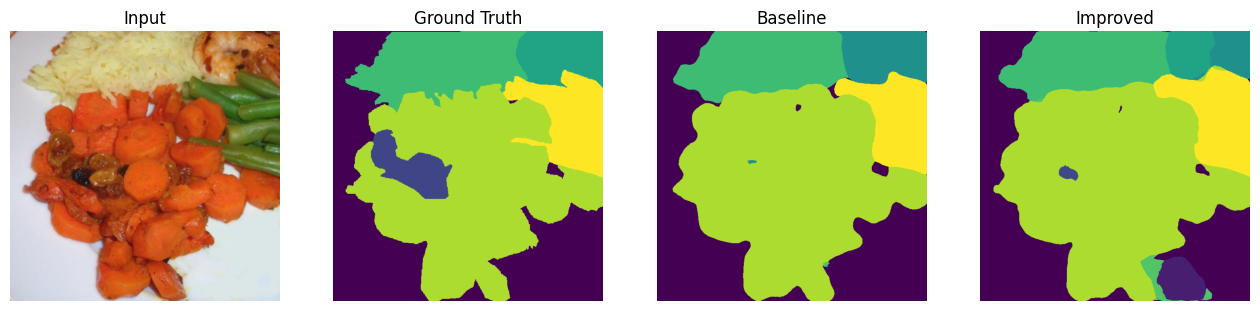

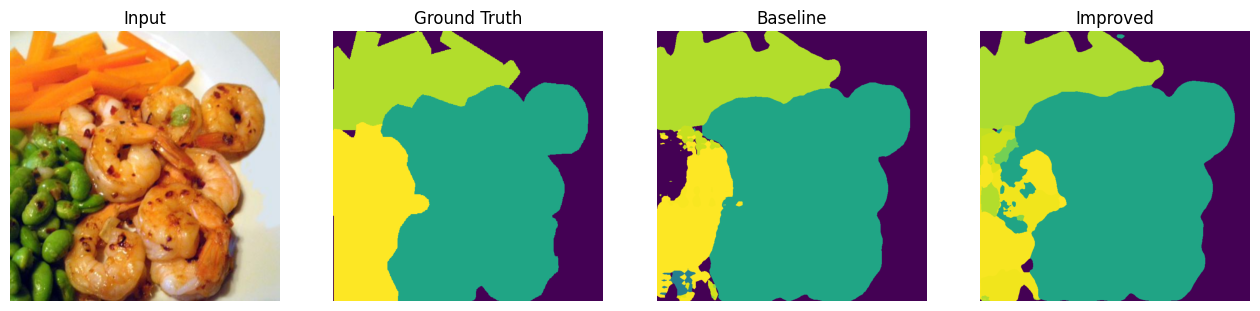

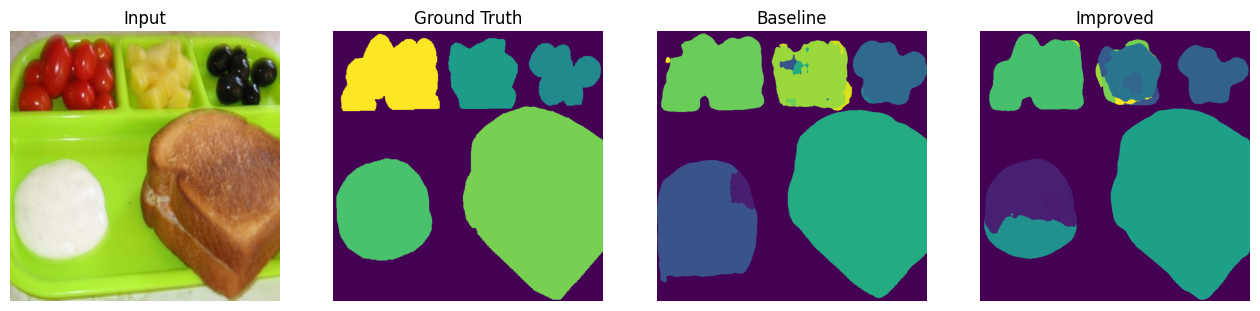

In [ ]:
images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    baseline_preds = torch.argmax(model(images), dim=1)
    improved_preds = torch.argmax(improved_model(images), dim=1)

images = images.cpu()
baseline_preds = baseline_preds.cpu()
improved_preds = improved_preds.cpu()
masks = masks.cpu()

####################
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img.clamp(0,1)
#################

for i in range(3):
    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.imshow(denormalize(images[i]).permute(1,2,0))
    #plt.imshow((images[i]).permute(1,2,0))
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(masks[i])
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(baseline_preds[i])
    plt.title("Baseline")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(improved_preds[i])
    plt.title("Improved")
    plt.axis("off")

    plt.show()

In [ ]:
# Install Transformers

!pip install -q transformers

print("Transformers installed.")

Transformers installed.


In [ ]:
# Build SegFormer Model

import torch
from transformers import SegformerForSemanticSegmentation

NUM_CLASSES = 104

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

segformer_model = segformer_model.cuda()

print("SegFormer Model Loaded Successfully")
print("Model on device:", next(segformer_model.parameters()).device)

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([104])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([104, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


SegFormer Model Loaded Successfully
Model on device: cuda:0


In [ ]:
# Optimizer & Scheduler

import torch.nn as nn

EPOCHS = 30
LEARNING_RATE = 5e-5

criterion = nn.CrossEntropyLoss()

optimizer_segformer = torch.optim.AdamW(
    segformer_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler_segformer = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_segformer,
    T_max=EPOCHS
)

print("Optimizer and Scheduler set successfully.")

Optimizer and Scheduler set successfully.


In [ ]:
# Create Checkpoint Paths

import os

SEGFORMER_SAVE_DIR = "/content/drive/MyDrive/CSC8645_Task1/segformer"
os.makedirs(SEGFORMER_SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SEGFORMER_SAVE_DIR, "segformer_best.pth")
LAST_MODEL_PATH = os.path.join(SEGFORMER_SAVE_DIR, "segformer_last.pth")

print("SegFormer checkpoints will be saved to:")
print(SEGFORMER_SAVE_DIR)

SegFormer checkpoints will be saved to:
/content/drive/MyDrive/CSC8645_Task1/segformer


In [ ]:
# mIoU Function

import numpy as np

def compute_miou(preds, labels, num_classes=104):
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()

    ious = []

    for cls in range(num_classes):
        pred_mask = (preds == cls)
        label_mask = (labels == cls)

        intersection = np.logical_and(pred_mask, label_mask).sum()
        union = np.logical_or(pred_mask, label_mask).sum()

        if union == 0:
            continue

        ious.append(intersection / union)

    if len(ious) == 0:
        return 0.0

    return np.mean(ious)

In [ ]:
# SegFormer Training

import torch.nn.functional as F
from tqdm import tqdm

best_miou_segformer = 0

train_losses = []
val_losses = []
train_mious = []
val_mious = []

for epoch in range(EPOCHS):

    # -----------------
    # TRAIN
    # -----------------
    segformer_model.train()
    train_loss = 0
    train_miou = 0

    for images, masks in tqdm(train_loader):
        images = images.cuda()
        masks = masks.long().cuda()

        optimizer_segformer.zero_grad()

        outputs = segformer_model(pixel_values=images)
        logits = outputs.logits

        # Upsample logits
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],  # match mask size
            mode="bilinear",
            align_corners=False
        )

        loss = criterion(logits, masks)
        loss.backward()
        optimizer_segformer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        train_miou += compute_miou(preds, masks)

    train_loss /= len(train_loader)
    train_miou /= len(train_loader)

    # VALIDATION
    segformer_model.eval()
    val_loss = 0
    val_miou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.cuda()
            masks = masks.long().cuda()

            outputs = segformer_model(pixel_values=images)
            logits = outputs.logits

            # VALIDATION
            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(logits, masks)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_miou += compute_miou(preds, masks)

    val_loss /= len(val_loader)
    val_miou /= len(val_loader)

    scheduler_segformer.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_mious.append(train_miou)
    val_mious.append(val_miou)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train mIoU: {train_miou:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val mIoU:   {val_miou:.4f}")

    # Save best
    if val_miou > best_miou_segformer:
        best_miou_segformer = val_miou
        torch.save(segformer_model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best model saved.")

# Save last model
torch.save(segformer_model.state_dict(), LAST_MODEL_PATH)

print("\nTraining Complete.")
print("Best SegFormer Val mIoU:", best_miou_segformer)

100%|██████████| 250/250 [02:41<00:00,  1.55it/s]



Epoch [1/30]
Train Loss: 2.7999 | Train mIoU: 0.0392
Val Loss:   2.0080 | Val mIoU:   0.0707
✅ Best model saved.


100%|██████████| 250/250 [02:39<00:00,  1.57it/s]



Epoch [2/30]
Train Loss: 1.8207 | Train mIoU: 0.0968
Val Loss:   1.6241 | Val mIoU:   0.1374
✅ Best model saved.


100%|██████████| 250/250 [02:39<00:00,  1.57it/s]


...


Epoch [28/30]
Train Loss: 0.2190 | Train mIoU: 0.5761
Val Loss:   1.0291 | Val mIoU:   0.3236


100%|██████████| 250/250 [02:39<00:00,  1.57it/s]



Epoch [29/30]
Train Loss: 0.2175 | Train mIoU: 0.5794
Val Loss:   1.0106 | Val mIoU:   0.3249


100%|██████████| 250/250 [02:39<00:00,  1.57it/s]



Epoch [30/30]
Train Loss: 0.2183 | Train mIoU: 0.5780
Val Loss:   1.0087 | Val mIoU:   0.3256

Training Complete.
Best SegFormer Val mIoU: 0.3264793510803617


In [ ]:
# Load Best Model

segformer_model.load_state_dict(torch.load(BEST_MODEL_PATH))
segformer_model.eval()

print("Best SegFormer model loaded.")

Best SegFormer model loaded.


In [ ]:
# Test Evaluation

import torch.nn.functional as F

test_miou = 0
segformer_model.eval()

with torch.no_grad():
    for images, masks in test_loader:

        images = images.cuda()
        masks = masks.long().cuda()

        outputs = segformer_model(pixel_values=images)
        logits = outputs.logits

        # Upsample logits to mask size
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        preds = torch.argmax(logits, dim=1)

        test_miou += compute_miou(preds, masks)

test_miou /= len(test_loader)

print("SegFormer Test mIoU:", test_miou)

SegFormer Test mIoU: 0.30228570991741155


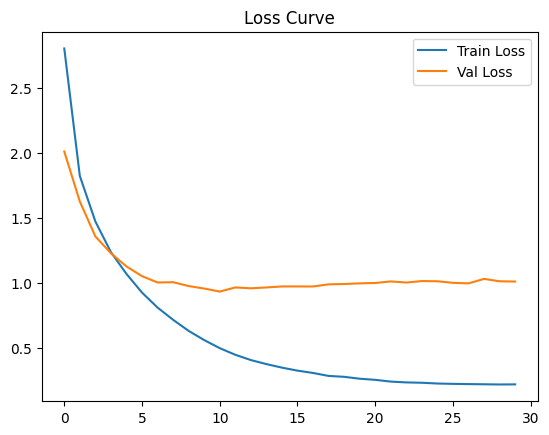

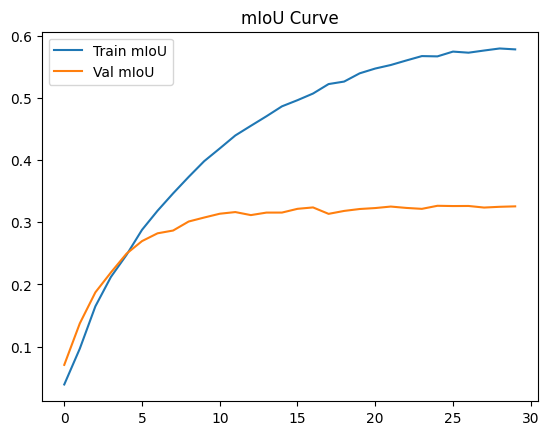

In [ ]:
# Plot Training Curves

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_mious, label="Train mIoU")
plt.plot(val_mious, label="Val mIoU")
plt.legend()
plt.title("mIoU Curve")
plt.show()

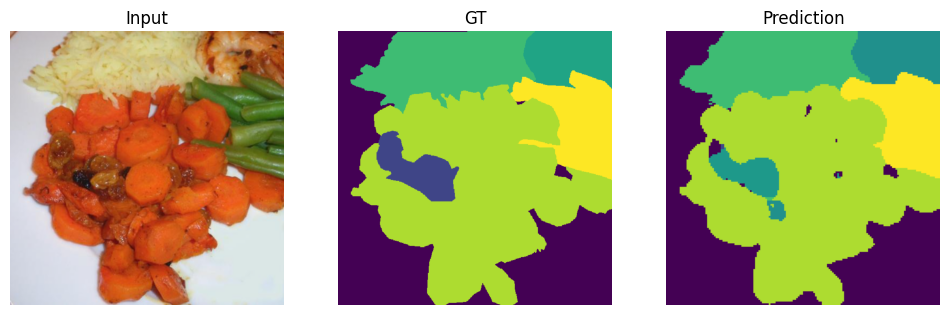

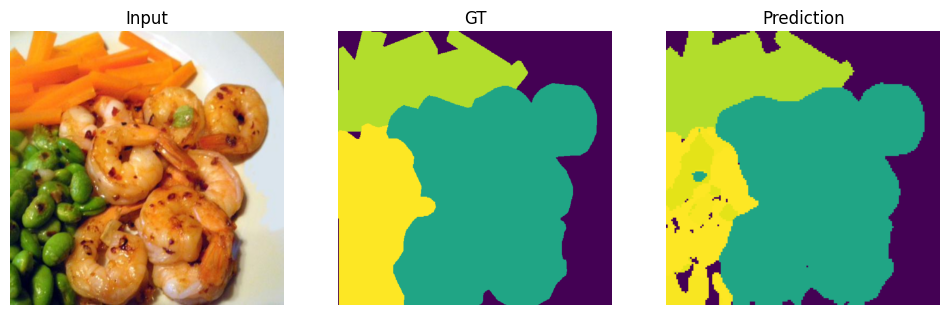

In [ ]:
# Visualise Predictions

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).cuda()
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).cuda()
    img = img * std + mean
    return img.clamp(0,1)

images, masks = next(iter(test_loader))
images = images.cuda()

with torch.no_grad():
    outputs = segformer_model(pixel_values=images)
    preds = torch.argmax(outputs.logits, dim=1)

for i in range(2):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    img = denormalize(images[i])
    plt.imshow(img.permute(1,2,0).cpu())
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(masks[i])
    plt.title("GT")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(preds[i].cpu())
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

In [ ]:
# ============================
# LOAD ALL MODELS
# ============================

import torch
import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F

DEVICE = "cuda"

NUM_CLASSES = 104

# -------- Baseline --------
baseline_model = smp.DeepLabV3(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
)
baseline_model.load_state_dict(torch.load("/content/drive/MyDrive/CSC8645_Task1/checkpoints/baseline_best.pth"))
baseline_model.to(DEVICE)
baseline_model.eval()

# -------- DeepLabV3+ --------
dlv3plus_model = smp.DeepLabV3Plus(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
)
dlv3plus_model.load_state_dict(torch.load("/content/drive/MyDrive/CSC8645_Task1/checkpoints/improved_best.pth"))
dlv3plus_model.to(DEVICE)
dlv3plus_model.eval()

# -------- SegFormer --------
segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
segformer_model.load_state_dict(torch.load("/content/drive/MyDrive/CSC8645_Task1/segformer/segformer_best.pth"))
segformer_model.to(DEVICE)
segformer_model.eval()

print("All models loaded successfully.")

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([104])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([104, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


All models loaded successfully.


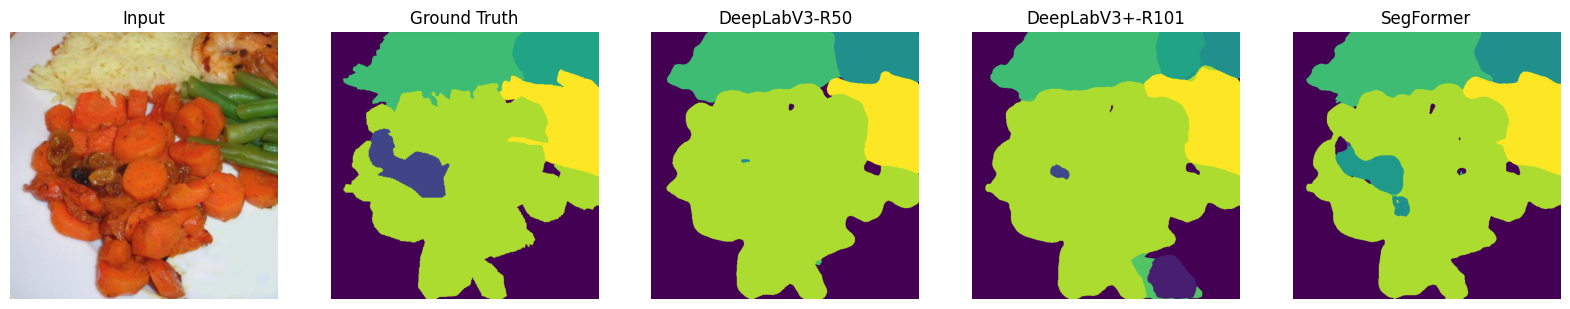

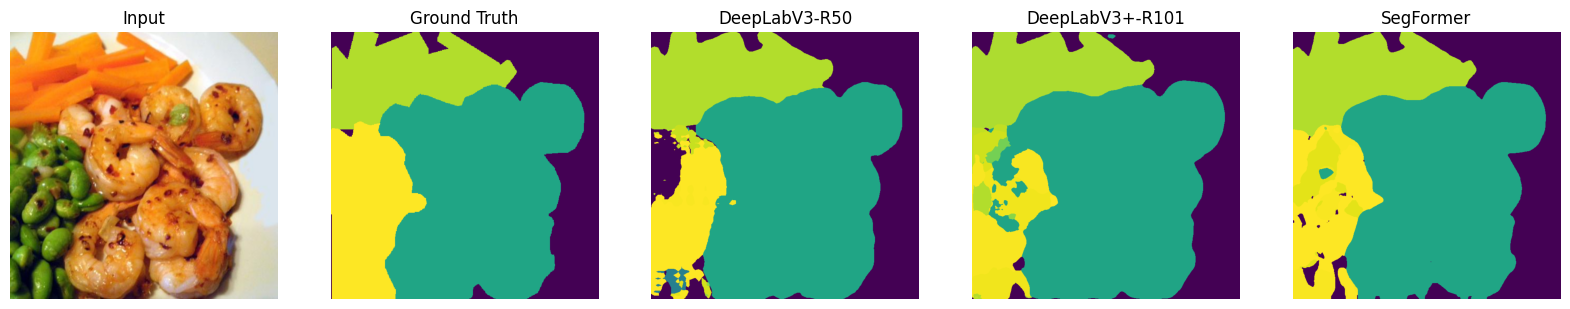

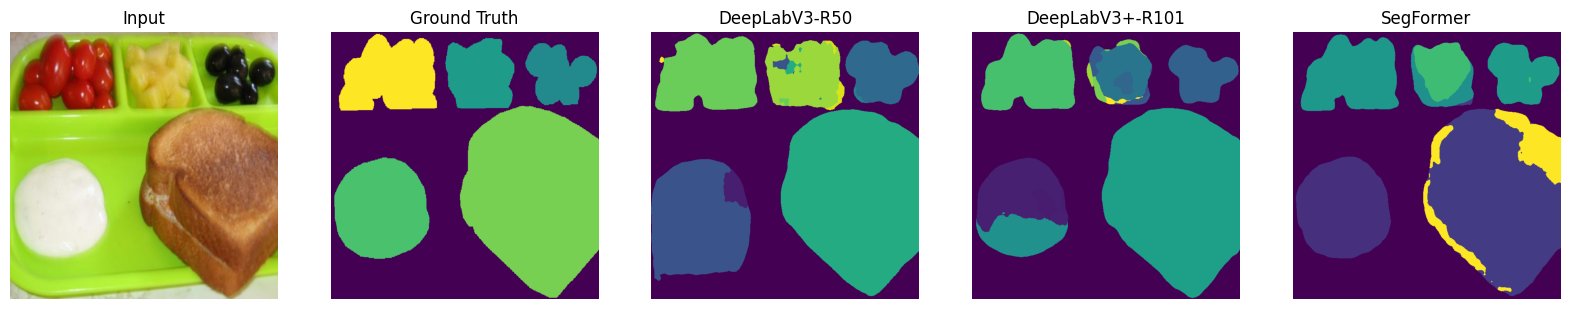

In [ ]:
# Visual Comparison (Test Set)

import matplotlib.pyplot as plt

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(img.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(img.device)
    img = img * std + mean
    return img.clamp(0,1)

# Get one batch from test set
images, masks = next(iter(test_loader))
images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():

    # Baseline
    out_base = baseline_model(images)
    pred_base = torch.argmax(out_base, dim=1)

    # DeepLabV3+
    out_plus = dlv3plus_model(images)
    pred_plus = torch.argmax(out_plus, dim=1)

    # SegFormer
    out_seg = segformer_model(pixel_values=images).logits
    out_seg = F.interpolate(out_seg, size=masks.shape[-2:], mode="bilinear", align_corners=False)
    pred_seg = torch.argmax(out_seg, dim=1)


# Show first 3 images
for i in range(3):

    plt.figure(figsize=(20,4))

    # Input
    plt.subplot(1,5,1)
    img = denormalize(images[i])
    plt.imshow(img.permute(1,2,0).cpu())
    plt.title("Input")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,5,2)
    plt.imshow(masks[i].cpu())
    plt.title("Ground Truth")
    plt.axis("off")

    # Baseline
    plt.subplot(1,5,3)
    plt.imshow(pred_base[i].cpu())
    plt.title("DeepLabV3-R50")
    plt.axis("off")

    # DeepLabV3+
    plt.subplot(1,5,4)
    plt.imshow(pred_plus[i].cpu())
    plt.title("DeepLabV3+-R101")
    plt.axis("off")

    # SegFormer
    plt.subplot(1,5,5)
    plt.imshow(pred_seg[i].cpu())
    plt.title("SegFormer")
    plt.axis("off")

    plt.show()

In [ ]:
# Compute Test mIoU for All Models

def evaluate_model(model, is_segformer=False):
    model.eval()
    total_miou = 0

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            if is_segformer:
                logits = model(pixel_values=images).logits
                logits = F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
            else:
                logits = model(images)

            preds = torch.argmax(logits, dim=1)
            total_miou += compute_miou(preds, masks)

    return total_miou / len(test_loader)


miou_base = evaluate_model(baseline_model)
miou_plus = evaluate_model(dlv3plus_model)
miou_seg = evaluate_model(segformer_model, is_segformer=True)

print("Test mIoU Results:")
print("DeepLabV3-R50:", miou_base)
print("DeepLabV3+-R101:", miou_plus)
print("SegFormer:", miou_seg)

Test mIoU Results:
DeepLabV3-R50: 0.26361818614209837
DeepLabV3+-R101: 0.2431955353338721
SegFormer: 0.30228570991741155


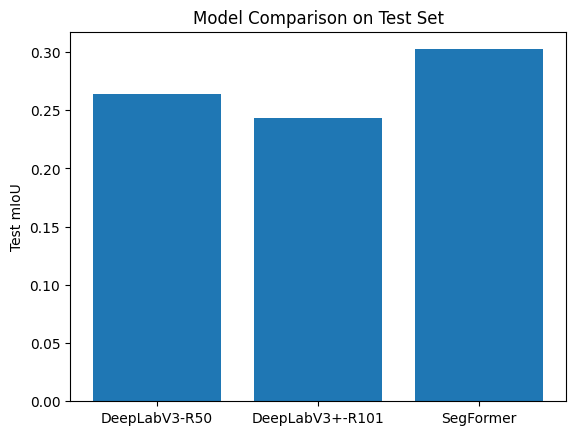

In [ ]:
import matplotlib.pyplot as plt

models = ["DeepLabV3-R50", "DeepLabV3+-R101", "SegFormer"]
mious = [miou_base, miou_plus, miou_seg]

plt.figure()
plt.bar(models, mious)
plt.ylabel("Test mIoU")
plt.title("Model Comparison on Test Set")
plt.show()

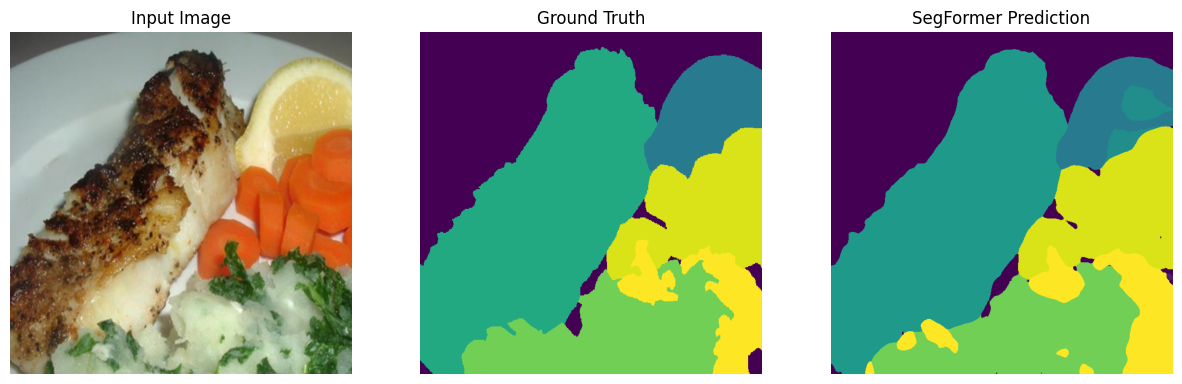

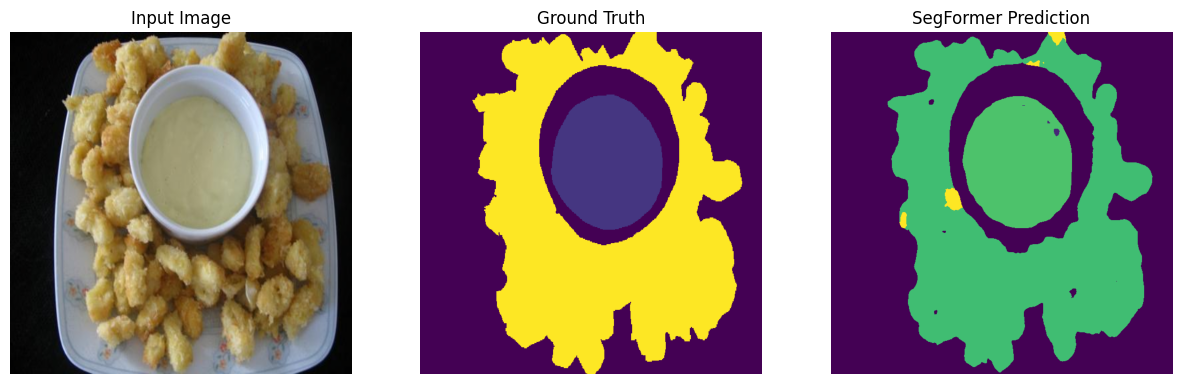

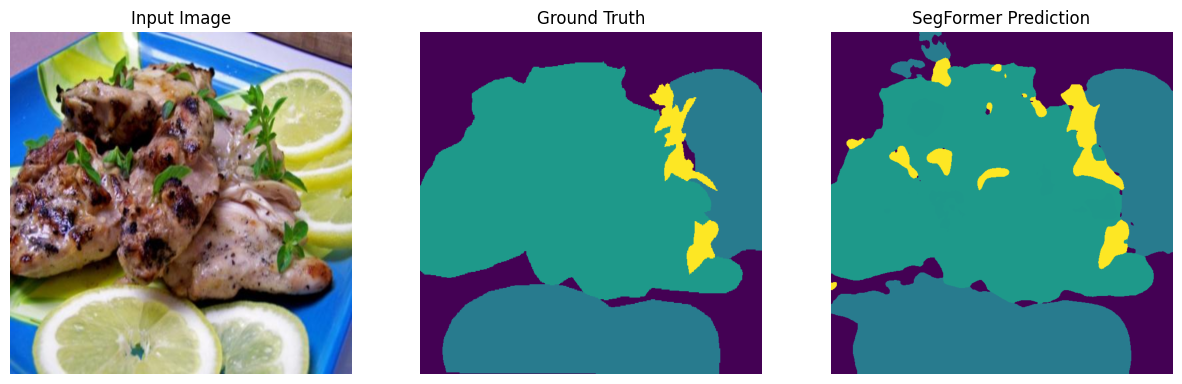

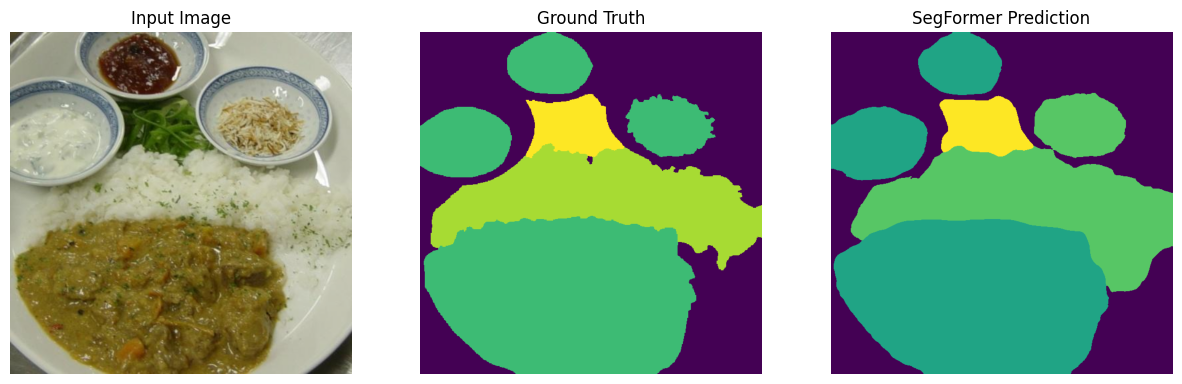

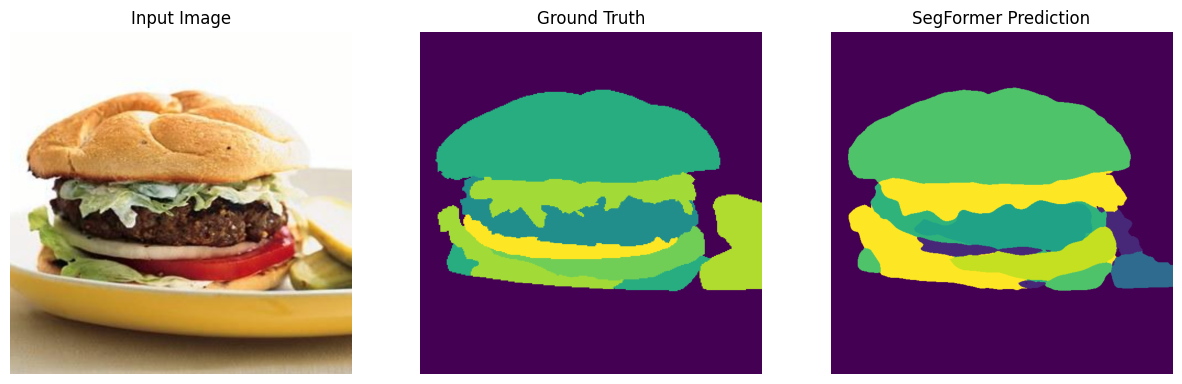

In [ ]:
# DEMONSTRATION
# 5 Random Test Images

import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = "cuda"

# Ensure best SegFormer is loaded
segformer_model.load_state_dict(torch.load(BEST_MODEL_PATH))
segformer_model.to(DEVICE)
segformer_model.eval()

# Denormalization function
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(img.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(img.device)
    img = img * std + mean
    return img.clamp(0,1)

# Randomly select 5 indices
random_indices = random.sample(range(len(test_loader.dataset)), 5)

for idx in random_indices:

    image, mask = test_loader.dataset[idx]

    image = image.unsqueeze(0).to(DEVICE)
    mask = mask.to(DEVICE)

    with torch.no_grad():
        outputs = segformer_model(pixel_values=image)
        logits = outputs.logits

        # Upsample to match ground truth size
        logits = F.interpolate(
            logits,
            size=mask.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        pred = torch.argmax(logits, dim=1).squeeze(0)

    # Plotting
    plt.figure(figsize=(15,5))

    # Input
    plt.subplot(1,3,1)
    img = denormalize(image.squeeze(0))
    plt.imshow(img.permute(1,2,0).cpu())
    plt.title("Input Image")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(mask.cpu())
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(pred.cpu())
    plt.title("SegFormer Prediction")
    plt.axis("off")

    plt.show()